# Model Comparison Report — EV Charging Load Demand Prediction
### All 7 Models · 5-Fold Cross-Validation · Thesis-Ready Visualisations

**Models covered:**  
Classical ML: Linear Regression · Decision Tree · Random Forest · XGBoost  
Deep Learning: ANN · LSTM · GRU  

**Run order:** Run ALL cells from top to bottom in one session.  
Each model section re-computes or accepts pre-loaded results, then the final section merges everything into comparison plots and tables.

## Section 0 — Installs & Imports

In [1]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import random, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, f1_score)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Input, Dropout, BatchNormalization,
                                      LSTM, GRU)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Full reproducibility
SEED = 42
os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS']  = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '2'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
tf.get_logger().setLevel('ERROR')

print('All imports done ✓')
print(f'TensorFlow: {tf.__version__}')

All imports done ✓
TensorFlow: 2.19.0


## Section 1 — Data Loading & Aggregation

In [2]:
df_raw = pd.read_csv('EV_Charging_Load_Demand_Dataset.csv')
print('Raw shape:', df_raw.shape)

# ── System-level aggregate (600 rows) — used by Classical ML & ANN ──────────
df_sys = df_raw.groupby('timestep_sec').agg({
    'minute_of_hour':                  'first',
    'system_total_load_kW':            'first',
    'system_total_vehicles':           'first',
    'system_moving_vehicles':          'first',
    'system_charging_vehicles':        'first',
    'system_waiting_vehicles':         'first',
    'system_avg_speed_ms':             'first',
    'system_avg_soc_percent':          'first',
    'system_avg_moving_speed_ms':      'first',
    'system_avg_moving_soc_percent':   'first',
    'system_avg_charging_soc_percent': 'first',
    'system_avg_charging_duration_sec':'first',
    'station_vehicles_charging':       'sum',
    'station_queue_length':            'sum',
    'station_utilization_percent':     'mean',
    'speed_ms':                        'mean',
    'acceleration_ms2':                'mean',
    'soc_percent':                     'mean',
    'energy_consumed_Wh':              'sum',
}).reset_index().sort_values('timestep_sec').reset_index(drop=True)

X_sys = df_sys.drop(columns=['system_total_load_kW', 'timestep_sec'])
y_sys = df_sys['system_total_load_kW']

# ── Raw data for LSTM/GRU (34020 rows, y = last column) ─────────────────────
X_seq_raw = df_raw.drop(columns=['vehicle_id','system_total_load_kW'], errors='ignore')
X_seq_raw = X_seq_raw.select_dtypes(include='number')
y_seq_raw = df_raw['system_total_load_kW']

# ── Shared KFold & bins ──────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

BINS   = [-1.0, 280.0, 830.0, 1165.0, 1400.0]
LABELS = ['Low (0–280)', 'Medium (280–830)', 'High (830–1165)', 'Peak (1165+)']
COLORS = {'Linear Regression':'#2196F3','Decision Tree':'#009688',
          'Random Forest':'#FF9800','XGBoost':'#F44336',
          'ANN':'#9C27B0','LSTM':'#E91E63','GRU':'#00BCD4'}

print(f'System-level: {X_sys.shape}  |  Raw seq: {X_seq_raw.shape}')
print(f'y range: {y_sys.min():.0f}–{y_sys.max():.0f} kW')

# ── Global results storage ───────────────────────────────────────────────────
REG_RESULTS = {}   # name → {MAE, MSE, RMSE, MAPE, R2}
CLS_RESULTS = {}   # name → {Acc, F1}
OOF_PREDS   = {}   # name → y_pred array (for scatter plots)
OOF_TRUE    = {}   # name → y_true array

def store_metrics(name, y_true, y_pred):
    """Compute & store all metrics for one model."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    nz   = np.asarray(y_true) != 0
    mape = np.mean(np.abs((np.asarray(y_true)[nz]-np.asarray(y_pred)[nz])/np.asarray(y_true)[nz]))*100
    acc  = 100 - mape

    y_tc = pd.cut(y_true, bins=BINS, labels=LABELS, include_lowest=True)
    ypc  = pd.cut(np.clip(y_pred, BINS[0]+1, BINS[-1]-1), bins=BINS, labels=LABELS, include_lowest=True)
    mask = ypc.notna()
    f1   = f1_score(y_tc[mask], ypc[mask], average='weighted', labels=LABELS, zero_division=0)

    REG_RESULTS[name] = dict(MAE=mae, MSE=mse, RMSE=rmse, MAPE=mape, R2=r2)
    CLS_RESULTS[name] = dict(Acc=acc, F1=f1)
    OOF_PREDS[name]   = pd.Series(y_pred)
    OOF_TRUE[name]    = pd.Series(y_true).reset_index(drop=True)
    print(f'  {name:<22} R²={r2:.4f}  MAE={mae:.2f}  RMSE={rmse:.2f}  Acc={acc:.2f}%  F1={f1:.4f}')

print('\nData & helpers ready ✓')

Raw shape: (34020, 25)
System-level: (600, 18)  |  Raw seq: (34020, 20)
y range: 0–1340 kW

Data & helpers ready ✓


## Section 2 — Classical ML Models (5-Fold CV)

In [3]:
print('Training Classical ML models...\n')

ml_models = {
    'Linear Regression': make_pipeline(StandardScaler(), Ridge(alpha=100)),
    'Decision Tree':     DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=50, max_depth=3,
                             min_samples_leaf=40, max_features=0.3, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=2,
                             subsample=0.55, colsample_bytree=0.6, min_child_weight=30,
                             reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
}

for name, model in ml_models.items():
    yp = cross_val_predict(model, X_sys, y_sys, cv=kf)
    store_metrics(name, y_sys.reset_index(drop=True), pd.Series(yp))

print('\nClassical ML complete ✓')

Training Classical ML models...

  Linear Regression      R²=0.9946  MAE=25.70  RMSE=32.69  Acc=94.53%  F1=0.8745
  Decision Tree          R²=0.9904  MAE=33.53  RMSE=43.55  Acc=92.61%  F1=0.8637
  Random Forest          R²=0.9878  MAE=39.71  RMSE=48.96  Acc=92.80%  F1=0.8506
  XGBoost                R²=0.9854  MAE=41.71  RMSE=53.52  Acc=93.46%  F1=0.8475

Classical ML complete ✓


## Section 3 — ANN (5-Fold CV, 150 epochs, no val_split)

In [4]:
def build_ann(input_dim, seed=42):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

y_pred_ann = np.zeros(len(y_sys))
print('Training ANN (5 folds × 150 epochs)...\n')

for fold, (tr, te) in enumerate(kf.split(X_sys), 1):
    X_tr_raw, X_te_raw = X_sys.iloc[tr].values, X_sys.iloc[te].values
    y_tr, y_te = y_sys.iloc[tr].values, y_sys.iloc[te].values
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_raw)
    X_te_s = sc.transform(X_te_raw)
    model = build_ann(X_sys.shape[1])
    model.fit(X_tr_s, y_tr, epochs=150, batch_size=16, verbose=0)
    y_pred_ann[te] = model.predict(X_te_s, verbose=0).squeeze()
    r2f = r2_score(y_te, y_pred_ann[te])
    print(f'  Fold {fold}: R²={r2f:.4f}')

store_metrics('ANN', y_sys.reset_index(drop=True), pd.Series(y_pred_ann))
print('\nANN complete ✓')

Training ANN (5 folds × 150 epochs)...

  Fold 1: R²=0.9958
  Fold 2: R²=0.9954
  Fold 3: R²=0.9982
  Fold 4: R²=0.9976
  Fold 5: R²=0.9966
  ANN                    R²=0.9967  MAE=19.20  RMSE=25.45  Acc=95.28%  F1=0.9234

ANN complete ✓


## Section 4 — LSTM & GRU (5-Fold CV, Window=5, 100 epochs)

In [5]:
WINDOW = 5

def create_sequences(X, y, window=5):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window]); ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

def run_seq_model(model_name, build_fn):
    """
    Runs 5-fold CV for LSTM or GRU.
    Uses raw 34020-row data with MinMaxScaler + sliding window sequences.
    """
    print(f'Training {model_name} (5 folds × 100 epochs)...\n')
    all_true, all_pred = [], []
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    for fold, (tr, te) in enumerate(kf.split(X_seq_raw), 1):
        X_tr_raw = X_seq_raw.iloc[tr].values
        X_te_raw = X_seq_raw.iloc[te].values
        y_tr_raw = y_seq_raw.iloc[tr].values.reshape(-1,1)
        y_te_raw = y_seq_raw.iloc[te].values.reshape(-1,1)

        sc_X = MinMaxScaler(); sc_y = MinMaxScaler()
        X_tr_s = sc_X.fit_transform(X_tr_raw)
        X_te_s = sc_X.transform(X_te_raw)
        y_tr_s = sc_y.fit_transform(y_tr_raw)
        y_te_s = sc_y.transform(y_te_raw)

        X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr_s.ravel(), WINDOW)
        X_te_seq, y_te_seq = create_sequences(X_te_s, y_te_s.ravel(), WINDOW)

        model = build_fn((X_tr_seq.shape[1], X_tr_seq.shape[2]))
        val_cut = int(len(X_tr_seq)*0.2)
        model.fit(X_tr_seq, y_tr_seq,
                  validation_data=(X_tr_seq[-val_cut:], y_tr_seq[-val_cut:]),
                  epochs=100, batch_size=32,
                  callbacks=[early_stop], verbose=0)

        y_pred_s = model.predict(X_te_seq, verbose=0).squeeze()
        y_pred_inv = sc_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()
        y_te_inv   = sc_y.inverse_transform(y_te_seq.reshape(-1,1)).ravel()

        all_true.extend(y_te_inv); all_pred.extend(y_pred_inv)
        r2f = r2_score(y_te_inv, y_pred_inv)
        print(f'  Fold {fold}: R²={r2f:.4f}')

    store_metrics(model_name,
                  pd.Series(all_true).reset_index(drop=True),
                  pd.Series(all_pred).reset_index(drop=True))
    print(f'{model_name} complete ✓\n')


def build_lstm(input_shape, seed=42):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    m = Sequential([Input(shape=input_shape),
                    LSTM(64, return_sequences=True), Dropout(0.2),
                    LSTM(32), Dropout(0.2),
                    Dense(16, activation='relu'), Dense(1)])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_gru(input_shape, seed=42):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    m = Sequential([Input(shape=input_shape),
                    GRU(64, return_sequences=True), Dropout(0.2),
                    GRU(32), Dropout(0.2),
                    Dense(16, activation='relu'), Dense(1)])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

run_seq_model('LSTM', build_lstm)
run_seq_model('GRU',  build_gru)

Training LSTM (5 folds × 100 epochs)...

  Fold 1: R²=0.9449
  Fold 2: R²=0.9366
  Fold 3: R²=0.9567
  Fold 4: R²=0.9313
  Fold 5: R²=0.9365
  LSTM                   R²=0.9411  MAE=80.00  RMSE=92.23  Acc=91.62%  F1=0.7089
LSTM complete ✓

Training GRU (5 folds × 100 epochs)...

  Fold 1: R²=0.9445
  Fold 2: R²=0.9544
  Fold 3: R²=0.9387
  Fold 4: R²=0.9440
  Fold 5: R²=0.9404
  GRU                    R²=0.9445  MAE=81.45  RMSE=89.60  Acc=90.76%  F1=0.7212
GRU complete ✓



## Section 5 — Summary Tables

In [6]:
MODEL_ORDER = ['Linear Regression','Decision Tree','Random Forest','XGBoost','ANN','LSTM','GRU']
MODEL_ORDER = [m for m in MODEL_ORDER if m in REG_RESULTS]

reg_df = pd.DataFrame([
    {'Model': m,
     'MAE (kW)':  round(REG_RESULTS[m]['MAE'],  3),
     'MSE (kW²)': round(REG_RESULTS[m]['MSE'],  1),
     'RMSE (kW)': round(REG_RESULTS[m]['RMSE'], 3),
     'MAPE (%)':  round(REG_RESULTS[m]['MAPE'], 4),
     'R² Score':  round(REG_RESULTS[m]['R2'],   4)}
    for m in MODEL_ORDER
])

cls_df = pd.DataFrame([
    {'Model': m,
     'Accuracy (%)':       round(CLS_RESULTS[m]['Acc'], 4),
     'F1-Score (Weighted)':round(CLS_RESULTS[m]['F1'],  4)}
    for m in MODEL_ORDER
])

full_df = reg_df.merge(cls_df, on='Model')

print('='*85)
print('  REGRESSION METRICS  —  5-Fold Cross-Validation')
print('='*85)
print(reg_df.to_string(index=False))
print()
print('='*55)
print('  CLASSIFICATION METRICS  —  5-Fold CV')
print('='*55)
print(cls_df.to_string(index=False))
print()
print('='*95)
print('  FULL COMPARISON TABLE')
print('='*95)
print(full_df.to_string(index=False))

  REGRESSION METRICS  —  5-Fold Cross-Validation
            Model  MAE (kW)  MSE (kW²)  RMSE (kW)  MAPE (%)  R² Score
Linear Regression    25.702     1068.8     32.693    5.4651    0.9946
    Decision Tree    33.530     1896.7     43.551    7.3891    0.9904
    Random Forest    39.705     2397.5     48.964    7.1994    0.9878
          XGBoost    41.712     2864.3     53.519    6.5354    0.9854
              ANN    19.205      647.9     25.454    4.7201    0.9967
             LSTM    80.000     8506.2     92.229    8.3835    0.9411
              GRU    81.451     8028.4     89.601    9.2374    0.9445

  CLASSIFICATION METRICS  —  5-Fold CV
            Model  Accuracy (%)  F1-Score (Weighted)
Linear Regression       94.5349               0.8745
    Decision Tree       92.6109               0.8637
    Random Forest       92.8006               0.8506
          XGBoost       93.4646               0.8475
              ANN       95.2799               0.9234
             LSTM       91.6165  

## Section 6 — Figure 1: Regression Metrics Comparison (Bar Charts)

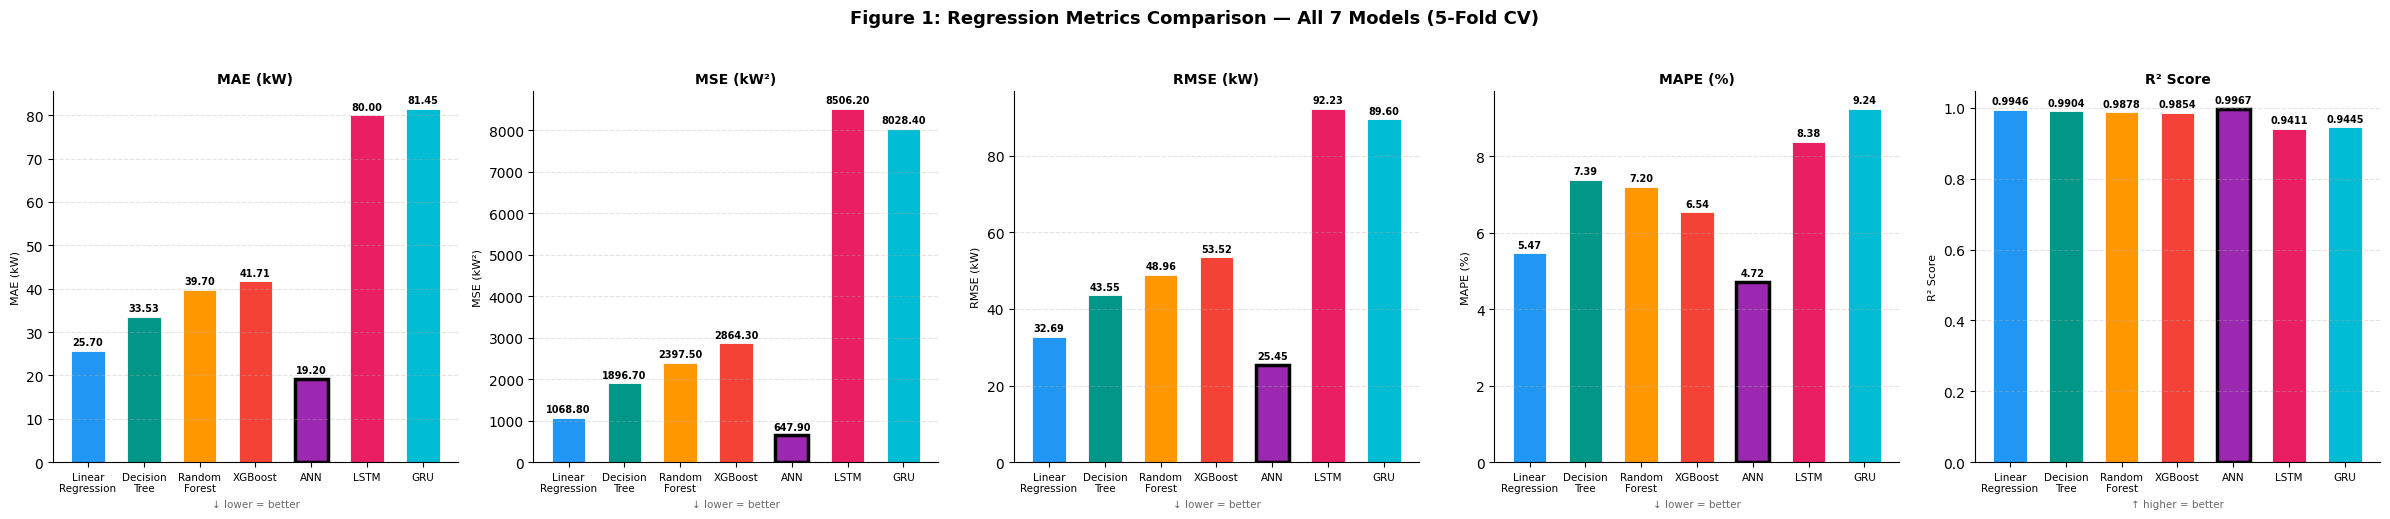

Saved → fig1_regression_metrics.png


In [9]:
bar_colors = [COLORS.get(m,'#607D8B') for m in MODEL_ORDER]
x = np.arange(len(MODEL_ORDER))
short_names = [m.replace(' ','\n') for m in MODEL_ORDER]

metrics_cfg = [
    ('MAE (kW)',  'MAE (kW)',  False),
    ('MSE (kW²)','MSE (kW²)', False),
    ('RMSE (kW)','RMSE (kW)', False),
    ('MAPE (%)','MAPE (%)',   False),
    ('R² Score', 'R² Score',  True),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Figure 1: Regression Metrics Comparison — All 7 Models (5-Fold CV)',
             fontsize=13, fontweight='bold', y=1.03)

for ax, (col, ylabel, higher) in zip(axes, metrics_cfg):
    vals = [full_df.loc[full_df['Model']==m, col].values[0] for m in MODEL_ORDER]
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='white', linewidth=0.6, width=0.6)
    best_idx = int(np.argmax(vals)) if higher else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('black'); bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if col=='R² Score' else f'{val:.2f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=7.5)
    ax.set_xlabel('↑ higher = better' if higher else '↓ lower = better',
                  fontsize=7.5, color='dimgray')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_regression_metrics.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig1_regression_metrics.png')

## Section 7 — Figure 2: Accuracy & F1-Score Comparison

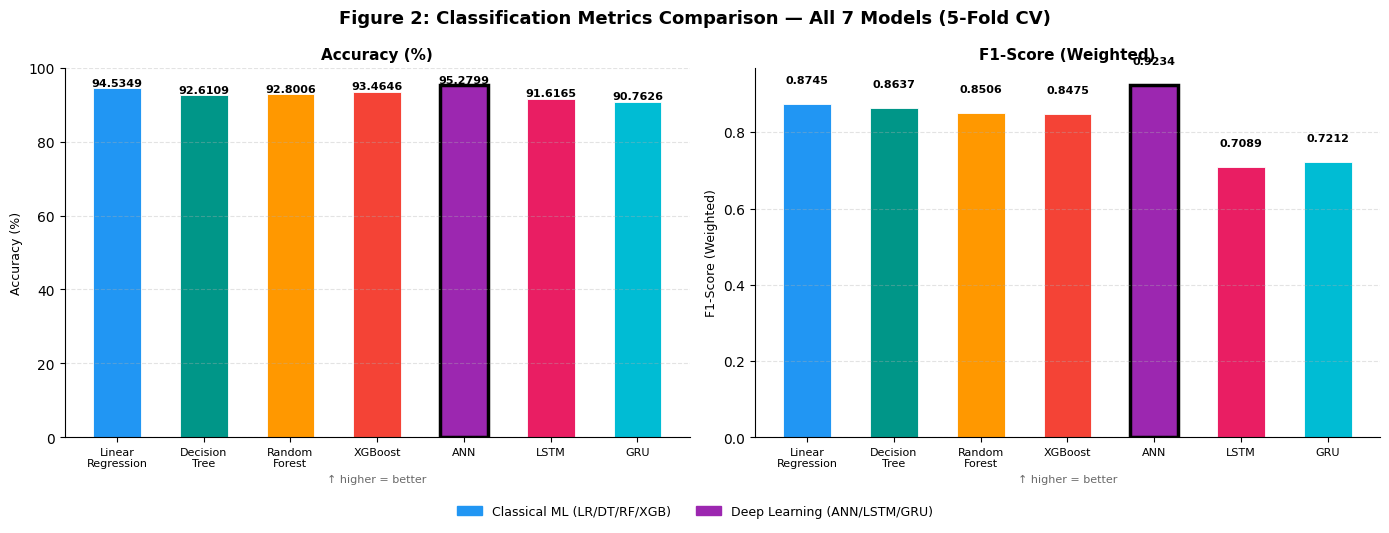

Saved → fig2_classification_metrics.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Classification Metrics Comparison — All 7 Models (5-Fold CV)',
             fontsize=13, fontweight='bold')

for ax, (col, ylabel) in zip(axes, [('Accuracy (%)','Accuracy (%)'),
                                      ('F1-Score (Weighted)','F1-Score (Weighted)')]):
    vals = [full_df.loc[full_df['Model']==m, col].values[0] for m in MODEL_ORDER]
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='white', linewidth=0.6, width=0.55)
    best = int(np.argmax(vals))
    bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(ylabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=8)
    ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top','right']].set_visible(False)

# Add legend for model category
handles = [mpatches.Patch(color='#2196F3',label='Classical ML (LR/DT/RF/XGB)'),
           mpatches.Patch(color='#9C27B0',label='Deep Learning (ANN/LSTM/GRU)')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5,-0.06), frameon=False)

plt.tight_layout()
plt.savefig('fig2_classification_metrics.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig2_classification_metrics.png')

## Section 8 — Figure 3: Full Score Comparison (Grouped Bar)

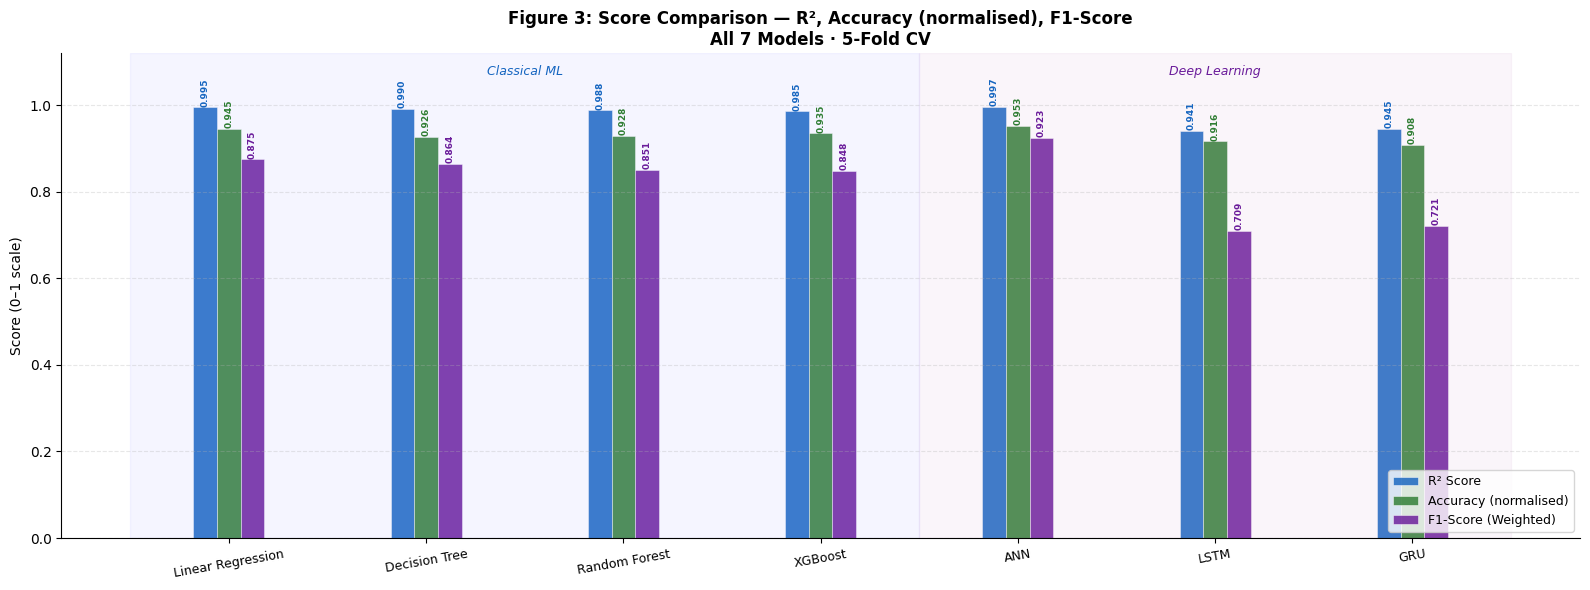

Saved → fig3_score_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(16, 6))

metrics_to_show = ['R² Score','Accuracy (%)','F1-Score (Weighted)']
n_metrics = len(metrics_to_show)
n_models  = len(MODEL_ORDER)
w = 0.12
offsets = np.linspace(-(n_metrics-1)*w/2, (n_metrics-1)*w/2, n_metrics)
metric_colors = ['#1565C0','#2E7D32','#6A1B9A']

for mi, (metric, mc_) in enumerate(zip(metrics_to_show, metric_colors)):
    if metric == 'R² Score':
        vals = [full_df.loc[full_df['Model']==m,'R² Score'].values[0] for m in MODEL_ORDER]
        label = 'R² Score'
    elif metric == 'Accuracy (%)':
        vals = [full_df.loc[full_df['Model']==m,'Accuracy (%)'].values[0]/100 for m in MODEL_ORDER]
        label = 'Accuracy (normalised)'
    else:
        vals = [full_df.loc[full_df['Model']==m,'F1-Score (Weighted)'].values[0] for m in MODEL_ORDER]
        label = 'F1-Score (Weighted)'

    bars = ax.bar(x + offsets[mi], vals, w,
                  color=mc_, alpha=0.82, label=label, edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold',
                color=mc_, rotation=90)

ax.set_title('''Figure 3: Score Comparison — R², Accuracy (normalised), F1-Score
All 7 Models · 5-Fold CV''',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0–1 scale)', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Shade classical vs deep learning
ax.axvspan(-0.5, 3.5, alpha=0.04, color='blue',  label='Classical ML')
ax.axvspan(3.5,  6.5, alpha=0.04, color='purple', label='Deep Learning')
ax.text(1.5,  1.07, 'Classical ML',  ha='center', fontsize=9, color='#1565C0', style='italic')
ax.text(5.0,  1.07, 'Deep Learning', ha='center', fontsize=9, color='#6A1B9A', style='italic')

plt.tight_layout()
plt.savefig('fig3_score_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig3_score_comparison.png')

## Section 9 — Figure 4: MAE vs R² Scatter (Model Positioning)

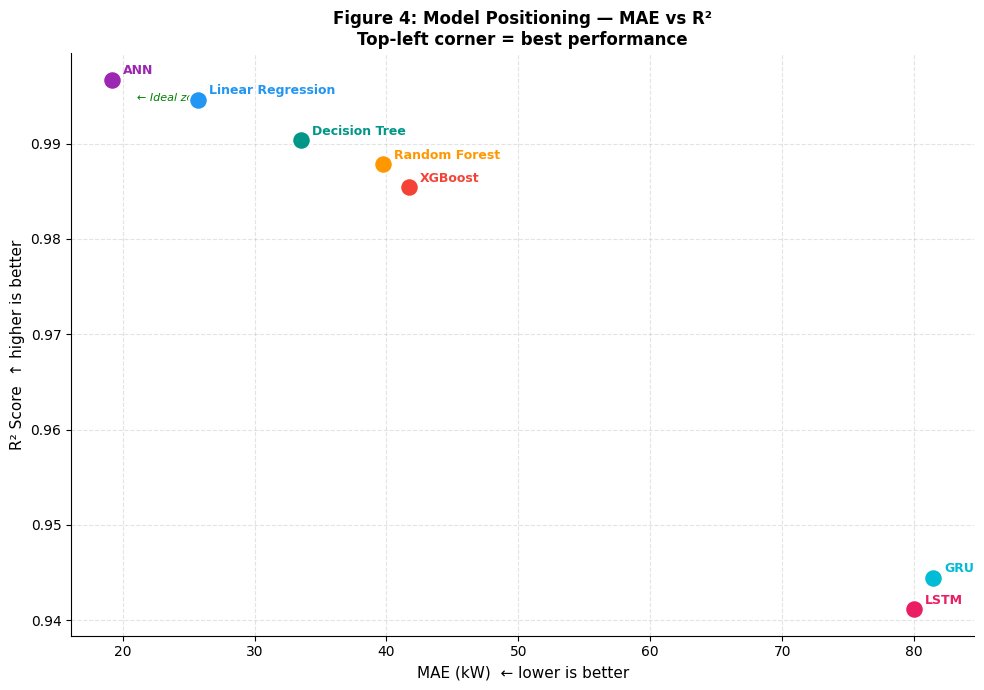

Saved → fig4_mae_vs_r2.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

for m in MODEL_ORDER:
    mae_v = REG_RESULTS[m]['MAE']
    r2_v  = REG_RESULTS[m]['R2']
    c     = COLORS.get(m,'#607D8B')
    ax.scatter(mae_v, r2_v, s=180, color=c, zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(m, (mae_v, r2_v),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=c, fontweight='bold')

ax.set_xlabel('MAE (kW)  ← lower is better', fontsize=11)
ax.set_ylabel('R² Score  ↑ higher is better', fontsize=11)
ax.set_title('Figure 4: Model Positioning — MAE vs R²\n'
             'Top-left corner = best performance', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)

# Annotate ideal zone
ax.annotate('← Ideal zone', xy=(ax.get_xlim()[0]+5, ax.get_ylim()[1]-0.005),
            fontsize=8, color='green', style='italic')

plt.tight_layout()
plt.savefig('fig4_mae_vs_r2.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig4_mae_vs_r2.png')

## Section 10 — Figure 5: Radar Chart (Normalised Metrics)

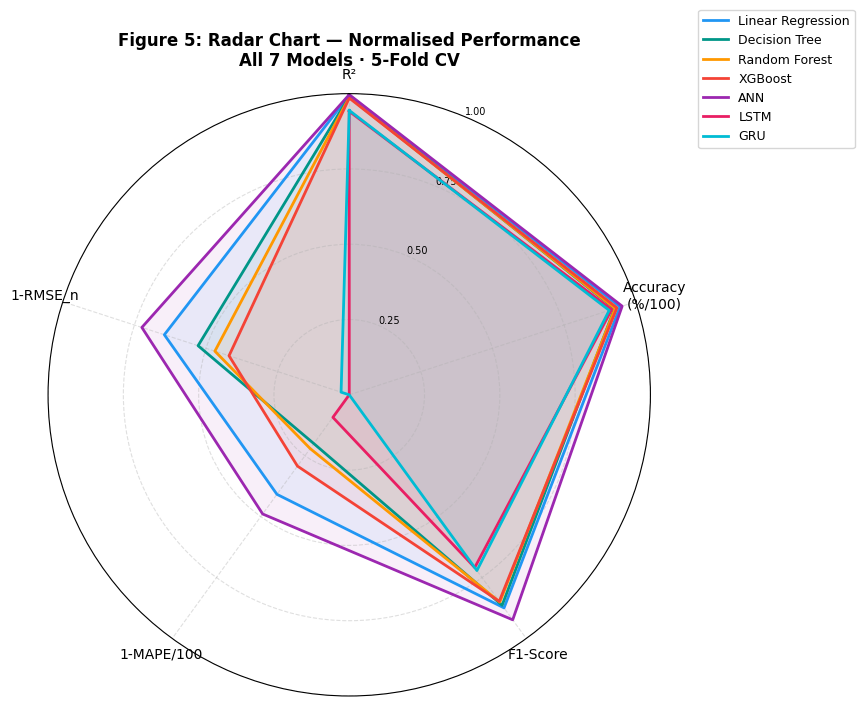

Saved → fig5_radar.png


In [15]:
from matplotlib.patches import FancyArrowPatch

categories = ['R²', 'Accuracy\n(%/100)', 'F1-Score', '1-MAPE/100', '1-RMSE_n']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0,1); ax.set_yticks([0.25,0.5,0.75,1.0])
ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=7)
ax.grid(True, linestyle='--', alpha=0.4)

# Normalise RMSE: best=0 worst=max
rmse_vals = [REG_RESULTS[m]['RMSE'] for m in MODEL_ORDER]
mape_vals = [REG_RESULTS[m]['MAPE'] for m in MODEL_ORDER]
rmse_max  = max(rmse_vals) + 1e-6
mape_max  = max(mape_vals) + 1e-6

for m in MODEL_ORDER:
    r  = REG_RESULTS[m]
    c  = CLS_RESULTS[m]
    vals = [
        r['R2'],
        c['Acc']/100,
        c['F1'],
        1 - r['MAPE']/mape_max,
        1 - r['RMSE']/rmse_max,
    ]
    vals += vals[:1]
    col = COLORS.get(m,'#607D8B')
    ax.plot(angles, vals, linewidth=2, linestyle='solid', color=col, label=m)
    ax.fill(angles, vals, color=col, alpha=0.07)

ax.set_title('Figure 5: Radar Chart — Normalised Performance\nAll 7 Models · 5-Fold CV',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('fig5_radar.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig5_radar.png')

## Section 11 — Figure 6: Actual vs Predicted (All 7 Models)

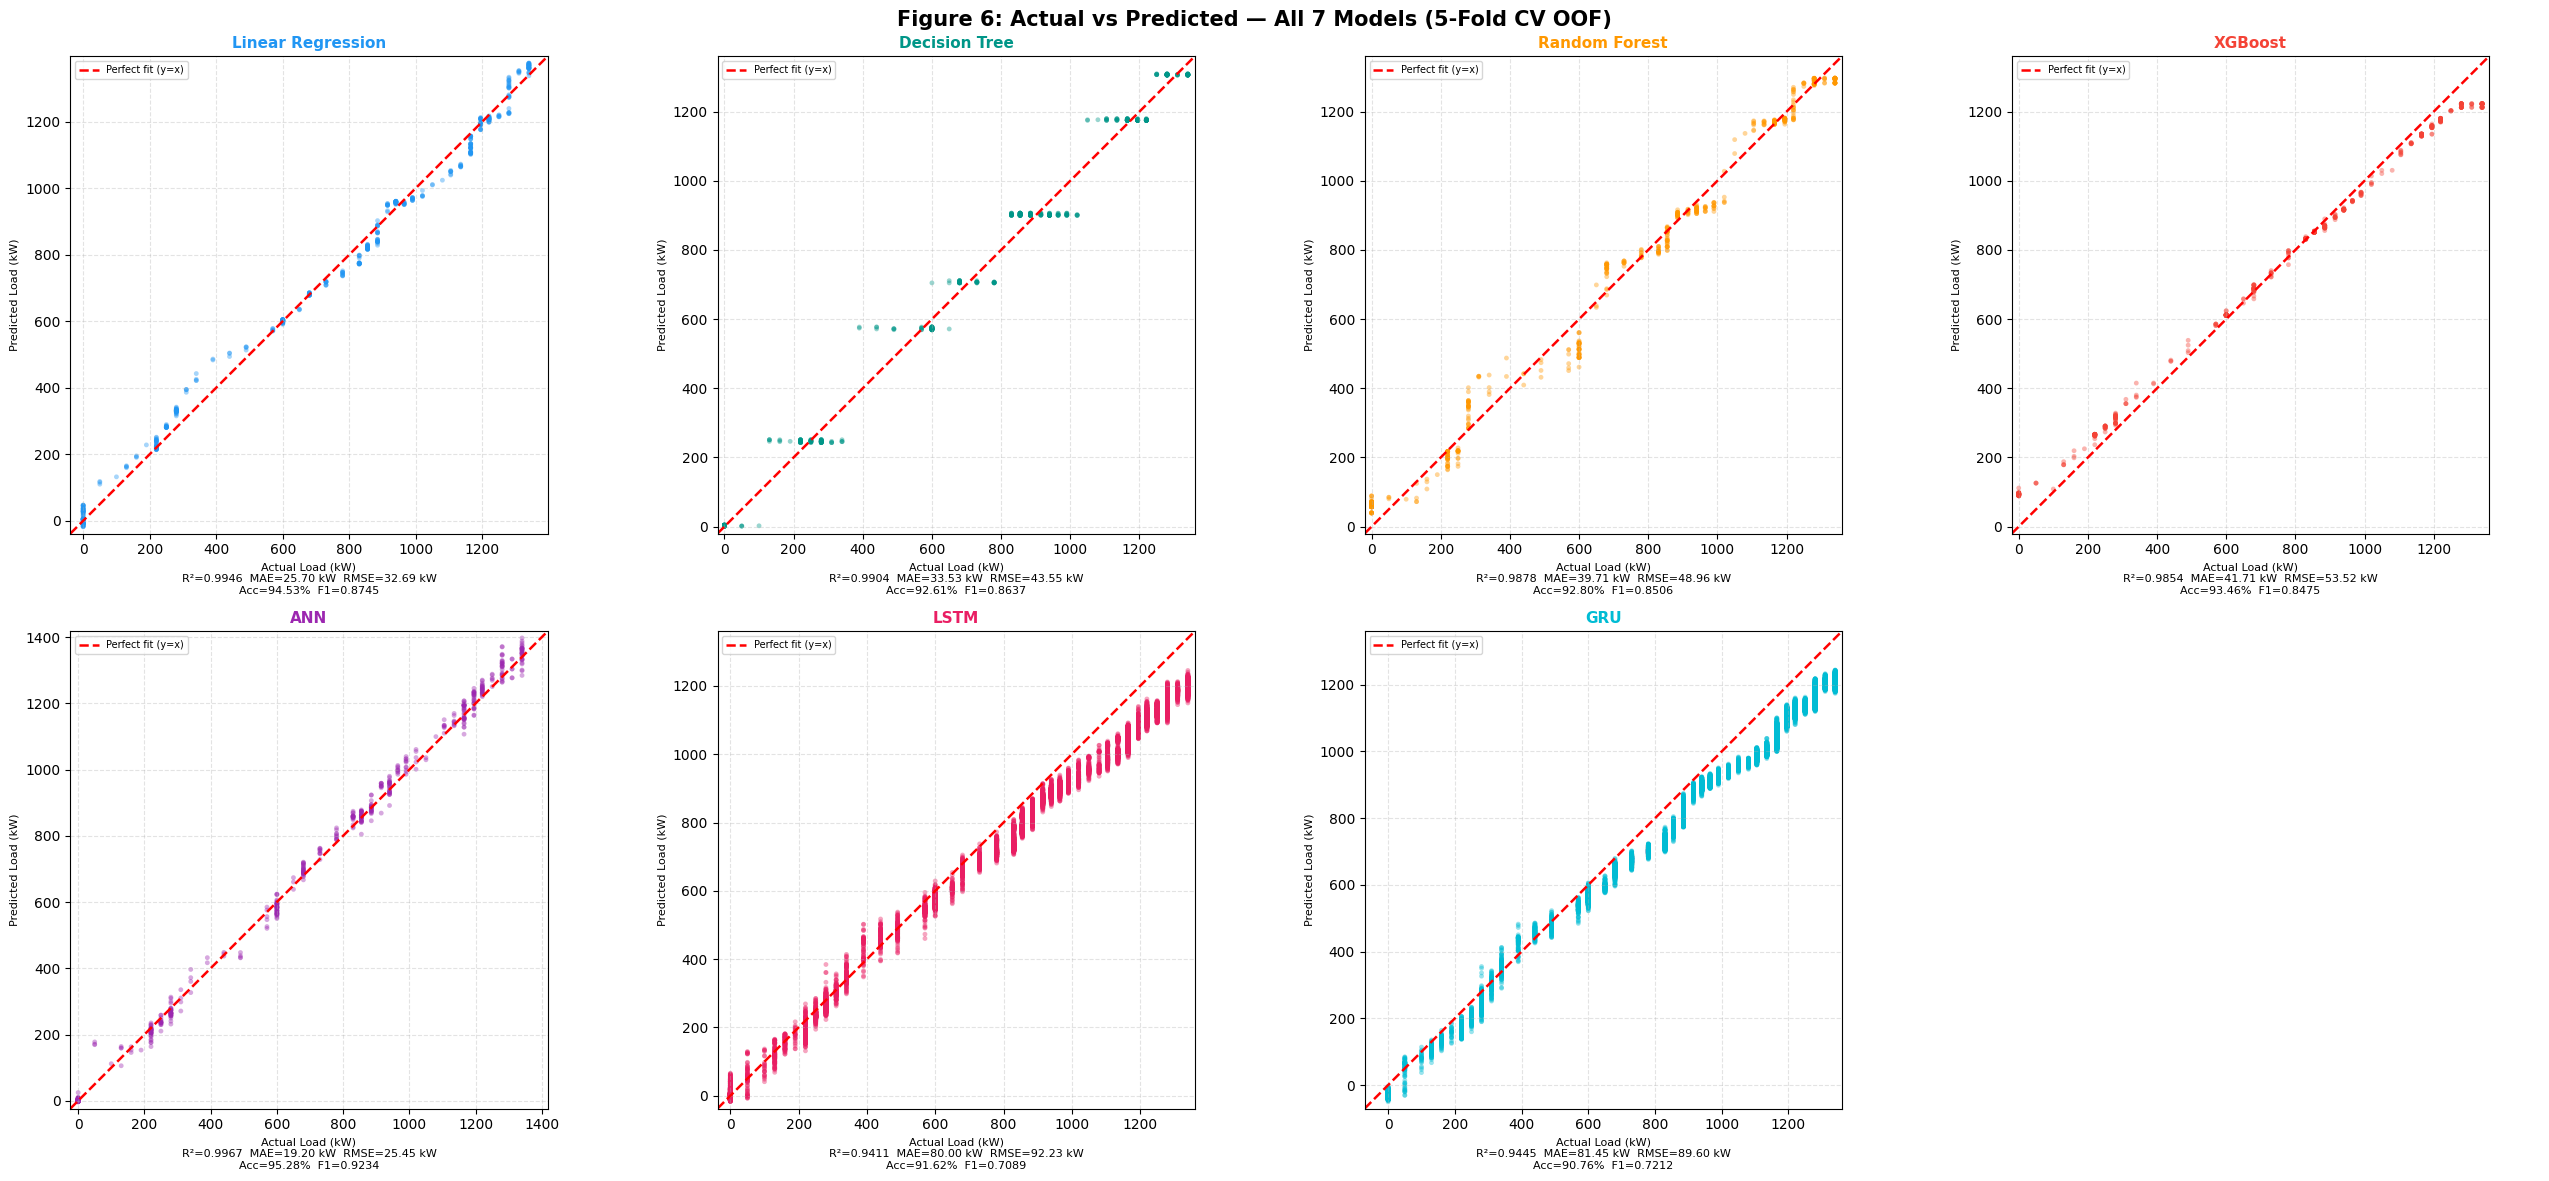

Saved → fig6_actual_vs_predicted.png


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(26, 12))
fig.suptitle('Figure 6: Actual vs Predicted — All 7 Models (5-Fold CV OOF)',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, m in enumerate(MODEL_ORDER):
    ax   = axes[i]
    yt   = OOF_TRUE[m].values
    yp   = OOF_PREDS[m].values
    col  = COLORS.get(m,'#607D8B')
    r    = REG_RESULTS[m]
    c    = CLS_RESULTS[m]

    lims = [min(yt.min(),yp.min())-20, max(yt.max(),yp.max())+20]
    ax.scatter(yt, yp, color=col, alpha=0.40, s=12, edgecolors='none')
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y=x)')
    ax.set_title(m, fontsize=11, fontweight='bold', color=col)
    ax.set_xlabel(
        f'Actual Load (kW)\n'
        f'R²={r["R2"]:.4f}  MAE={r["MAE"]:.2f} kW  RMSE={r["RMSE"]:.2f} kW\n'
        f'Acc={c["Acc"]:.2f}%  F1={c["F1"]:.4f}',
        fontsize=8)
    ax.set_ylabel('Predicted Load (kW)', fontsize=8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.35)

axes[-1].axis('off')   # hide the 8th panel (empty)

plt.tight_layout()
plt.savefig('fig6_actual_vs_predicted.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig6_actual_vs_predicted.png')

## Section 12 — Figure 7: Styled Heatmap Table (Thesis-Ready)

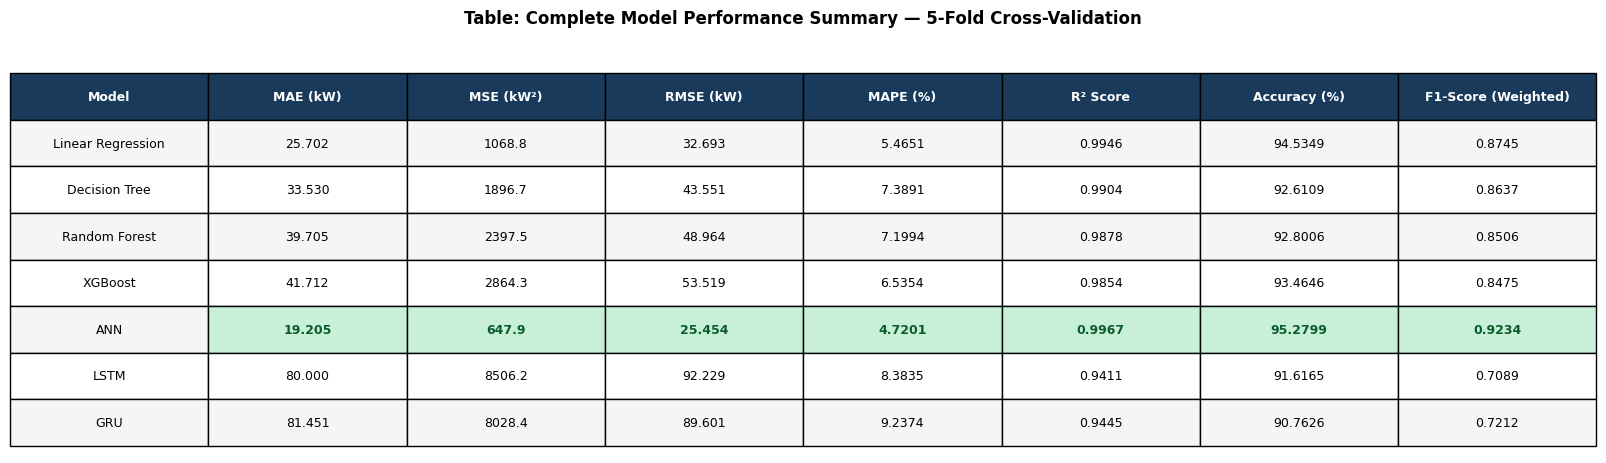

Saved → fig7_summary_table.png


In [20]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.axis('off')
fig.suptitle('Table: Complete Model Performance Summary — 5-Fold Cross-Validation',
             fontsize=12, fontweight='bold', y=1.02)

col_labels = ['Model','MAE (kW)','MSE (kW²)','RMSE (kW)','MAPE (%)','R² Score','Accuracy (%)','F1-Score (Weighted)']
cell_text  = []
for m in MODEL_ORDER:
    r = REG_RESULTS[m]; c = CLS_RESULTS[m]
    cell_text.append([m,
                       f'{r["MAE"]:.3f}', f'{r["MSE"]:.1f}',
                       f'{r["RMSE"]:.3f}', f'{r["MAPE"]:.4f}',
                       f'{r["R2"]:.4f}', f'{c["Acc"]:.4f}',
                       f'{c["F1"]:.4f}'])

table = ax.table(cellText=cell_text, colLabels=col_labels,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.2, 2.5)

# Header
for j in range(len(col_labels)):
    table[0,j].set_facecolor('#1a3a5c')
    table[0,j].set_text_props(color='white', fontweight='bold')

# Row alternating + best highlight
row_colors = ['#f5f5f5','#ffffff','#f5f5f5','#ffffff','#f5f5f5','#ffffff','#f5f5f5']

# Find best per metric column
col_idx_map = {1:'MAE', 2:'MSE', 3:'RMSE', 4:'MAPE', 5:'R2', 6:'Acc', 7:'F1'}
best_row = {}
for cidx, key in col_idx_map.items():
    vals = [REG_RESULTS[m][key] if key in REG_RESULTS[m] else CLS_RESULTS[m][key]
            for m in MODEL_ORDER]
    higher = key in ['R2','Acc','F1']
    best_row[cidx] = int(np.argmax(vals)) if higher else int(np.argmin(vals))

for i in range(len(MODEL_ORDER)):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(row_colors[i])
        if j in best_row and best_row[j]==i:
            table[i+1,j].set_facecolor('#c8f0d8')
            table[i+1,j].set_text_props(fontweight='bold', color='#0a5c2a')

plt.tight_layout()
plt.savefig('fig7_summary_table.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig7_summary_table.png')

## Section 13 — Download All Figures

In [22]:
from google.colab import files

figures = [
    'fig1_regression_metrics.png',
    'fig2_classification_metrics.png',
    'fig3_score_comparison.png',
    'fig4_mae_vs_r2.png',
    'fig5_radar.png',
    'fig6_actual_vs_predicted.png',
    'fig7_summary_table.png',
]
for f in figures:
    files.download(f)
    print(f'Downloaded → {f}')
print('\nAll downloads complete ✓')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → fig1_regression_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded → fig6_actual_vs_predicted.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → fig7_summary_table.png

All downloads complete ✓
